In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print(df.shape)

(100000, 26)


In [6]:
print("Number of students:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
for column in df.columns:
    print(column)

print("\nTarget Variable:")
print("placement_status")

Number of students: 100000
Number of columns: 26

Column Names:
student_id
age
gender
cgpa
branch
college_tier
internships_count
projects_count
certifications_count
coding_skill_score
aptitude_score
communication_skill_score
logical_reasoning_score
hackathons_participated
github_repos
linkedin_connections
mock_interview_score
attendance_percentage
backlogs
extracurricular_score
leadership_score
volunteer_experience
sleep_hours
study_hours_per_day
placement_status
salary_package_lpa

Target Variable:
placement_status


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
student_id                   100000
age                               7
gender                            2
cgpa                            551
branch                            6
college_tier                      3
internships_count                 9
projects_count                   14
certifications_count             12
coding_skill_score            97643
aptitude_score                98859
communication_skill_score     98872
logical_reasoning_score       98730
hackathons_participated           9
github_repos                     16
linkedin_connections            950
mock_interview_score          99352
attendance_percentage         93397
backlogs                          7
extracurricular_score         97660
leadership_score              98473
volunteer_experience              2
sleep_hours                      71
study_hours_per_day              92
placement_status                  2
salary_package_lpa             1047
dtype: int64


In [11]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [12]:
print("Placement Status Distribution:")
print(df["placement_status"].value_counts())

Placement Status Distribution:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


In [13]:
print("\nPlacement Status Percentage:")
print(df["placement_status"].value_counts(normalize=True) * 100)


Placement Status Percentage:
placement_status
Placed        54.459
Not Placed    45.541
Name: proportion, dtype: float64


In [14]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)

Original shape: (100000, 26)
Clean dataset shape: (100000, 26)


In [15]:
# Remove columns that should not be used for prediction

df_clean = df_clean.drop(
    columns=["student_id", "salary_package_lpa"]
)

print("Shape after removing columns:", df_clean.shape)

Shape after removing columns: (100000, 24)


In [16]:
# Convert placement status to numerical values

df_clean["placement_status"] = df_clean["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})

print(df_clean["placement_status"].value_counts())

placement_status
1    54459
0    45541
Name: count, dtype: int64


In [18]:
print(df_clean["placement_status"].dtype)

int64


In [19]:
# TASK 3 — Final Verification

print("Dataset shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nMissing values:")
print(df_clean.isnull().sum().sum())

print("\nTarget data type:")
print(df_clean["placement_status"].dtype)

Dataset shape: (100000, 24)

Columns:
['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status']

Missing values:
0

Target data type:
int64


In [20]:
df_clean.describe()

,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,placement_status
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,1.000690,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,0.54459
std,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,0.997908,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,0.49801
min,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,0.000000,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.00000
25%,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,0.000000,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.00000
50%,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,1.000000,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,1.00000
75%,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,2.000000,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,1.00000
max,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,8.000000,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,1.00000


In [21]:
df_clean.describe(include="object")

,gender,branch,college_tier,volunteer_experience
count,100000,100000,100000,100000
unique,2,6,3,2
top,Male,CSE,Tier 2,No
freq,60028,34818,49955,59963


In [22]:
cgpa_by_placement = df_clean.groupby("placement_status")["cgpa"].mean()

print(cgpa_by_placement)

placement_status
0    7.483789
1    7.507846
Name: cgpa, dtype: float64


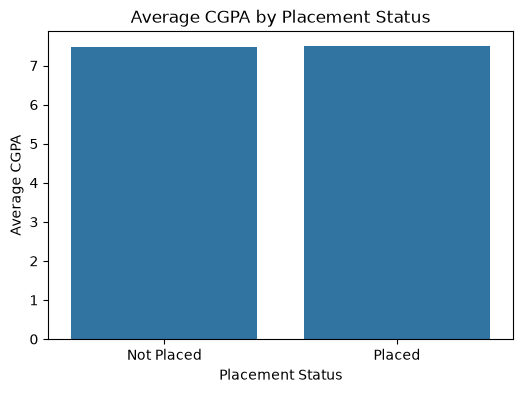

In [23]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=cgpa_by_placement.index,
    y=cgpa_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.title("Average CGPA by Placement Status")

plt.show()

In [25]:
internship_placement = pd.crosstab(
    df_clean["internships_count"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(internship_placement)

placement_status           0          1
internships_count                      
0                  49.682475  50.317525
1                  46.297621  53.702379
2                  44.600247  55.399753
3                  42.048796  57.951204
4                  40.055782  59.944218
5                  34.631148  65.368852
6                  26.744186  73.255814
7                  27.027027  72.972973
8                  27.272727  72.727273


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load original dataset
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")

# Create clean dataset
df_clean = df.copy()

# Remove identifier and target-leakage column
df_clean = df_clean.drop(
    columns=["student_id", "salary_package_lpa"]
)

# Convert target to numerical values
df_clean["placement_status"] = df_clean["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})

print("df_clean recreated successfully!")
print("Shape:", df_clean.shape)

df_clean recreated successfully!
Shape: (100000, 24)


In [5]:
internship_placement = pd.crosstab(
    df_clean["internships_count"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(internship_placement)

placement_status           0          1
internships_count                      
0                  49.682475  50.317525
1                  46.297621  53.702379
2                  44.600247  55.399753
3                  42.048796  57.951204
4                  40.055782  59.944218
5                  34.631148  65.368852
6                  26.744186  73.255814
7                  27.027027  72.972973
8                  27.272727  72.727273


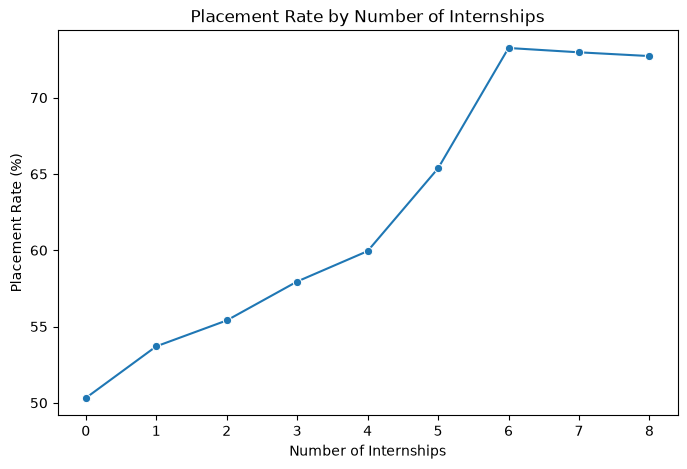

In [6]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    x=internship_placement.index,
    y=internship_placement[1],
    marker="o"
)

plt.xlabel("Number of Internships")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Number of Internships")
plt.xticks(internship_placement.index)

plt.show()

In [7]:
internship_placement = pd.crosstab(
    df_clean["internships_count"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(internship_placement)

placement_status           0          1
internships_count                      
0                  49.682475  50.317525
1                  46.297621  53.702379
2                  44.600247  55.399753
3                  42.048796  57.951204
4                  40.055782  59.944218
5                  34.631148  65.368852
6                  26.744186  73.255814
7                  27.027027  72.972973
8                  27.272727  72.727273


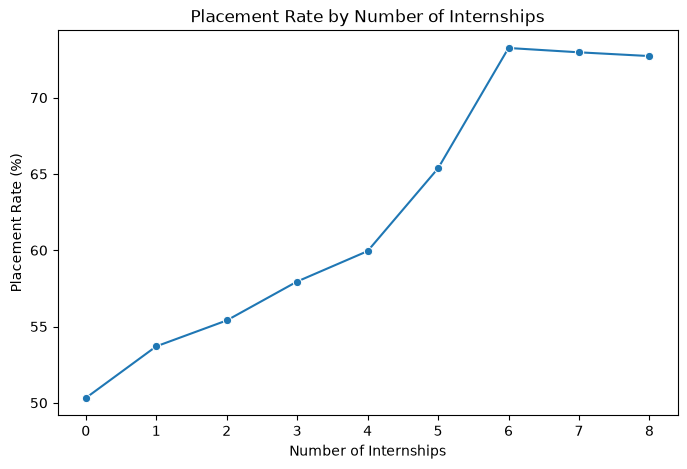

In [8]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    x=internship_placement.index,
    y=internship_placement[1],
    marker="o"
)

plt.xlabel("Number of Internships")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Number of Internships")
plt.xticks(internship_placement.index)

plt.show()

In [9]:
projects_placement = pd.crosstab(
    df_clean["projects_count"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(projects_placement)

placement_status          0           1
projects_count                         
0                 50.909458   49.090542
1                 48.760054   51.239946
2                 47.212645   52.787355
3                 45.697131   54.302869
4                 44.192517   55.807483
5                 41.419126   58.580874
6                 40.794893   59.205107
7                 40.097475   59.902525
8                 34.451613   65.548387
9                 28.825623   71.174377
10                27.160494   72.839506
11                28.125000   71.875000
12                20.000000   80.000000
13                 0.000000  100.000000


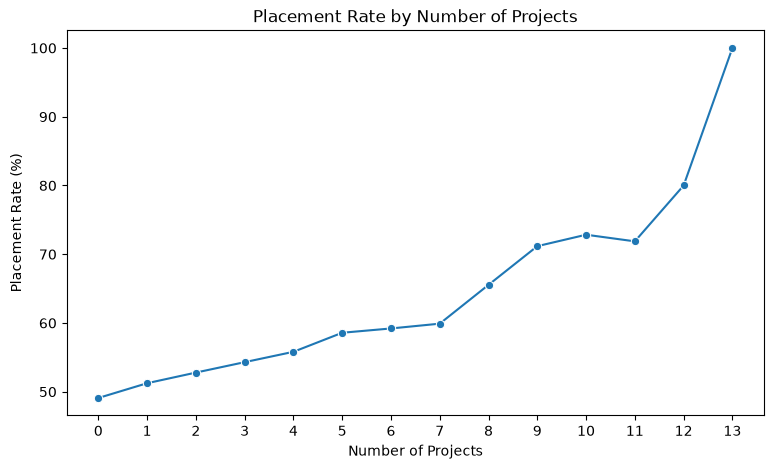

In [10]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    x=projects_placement.index,
    y=projects_placement[1],
    marker="o"
)

plt.xlabel("Number of Projects")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Number of Projects")
plt.xticks(projects_placement.index)

plt.show()

In [11]:
coding_by_placement = df_clean.groupby("placement_status")["coding_skill_score"].mean()

print(coding_by_placement)

placement_status
0    69.009449
1    70.507598
Name: coding_skill_score, dtype: float64


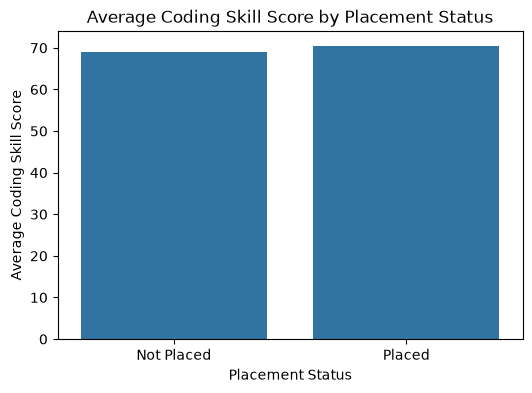

In [12]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=coding_by_placement.index,
    y=coding_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average Coding Skill Score")
plt.title("Average Coding Skill Score by Placement Status")

plt.show()

In [13]:
coding_by_placement = df_clean.groupby("placement_status")["coding_skill_score"].mean()

print(coding_by_placement)

placement_status
0    69.009449
1    70.507598
Name: coding_skill_score, dtype: float64


In [14]:
aptitude_by_placement = df_clean.groupby("placement_status")["aptitude_score"].mean()

print(aptitude_by_placement)

placement_status
0    64.473703
1    65.418276
Name: aptitude_score, dtype: float64


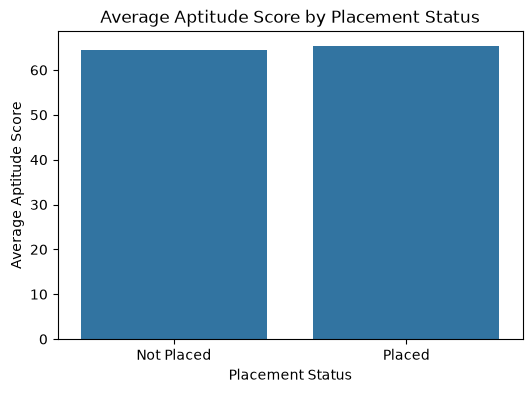

In [15]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=aptitude_by_placement.index,
    y=aptitude_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average Aptitude Score")
plt.title("Average Aptitude Score by Placement Status")

plt.show()


In [16]:
communication_by_placement = df_clean.groupby(
    "placement_status"
)["communication_skill_score"].mean()

print(communication_by_placement)

placement_status
0    67.472542
1    68.368999
Name: communication_skill_score, dtype: float64


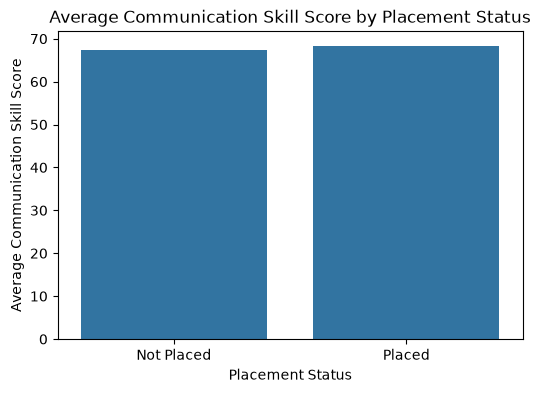

In [17]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=communication_by_placement.index,
    y=communication_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average Communication Skill Score")
plt.title("Average Communication Skill Score by Placement Status")

plt.show()

In [18]:
logical_reasoning_by_placement = df_clean.groupby(
    "placement_status"
)["logical_reasoning_score"].mean()

print(logical_reasoning_by_placement)

placement_status
0    65.342630
1    66.424298
Name: logical_reasoning_score, dtype: float64


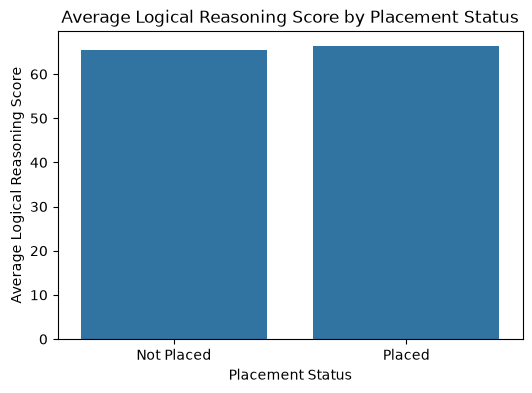

In [19]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=logical_reasoning_by_placement.index,
    y=logical_reasoning_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average Logical Reasoning Score")
plt.title("Average Logical Reasoning Score by Placement Status")

plt.show()

In [20]:
mock_interview_by_placement = df_clean.groupby(
    "placement_status"
)["mock_interview_score"].mean()

print(mock_interview_by_placement)

placement_status
0    69.388182
1    70.492185
Name: mock_interview_score, dtype: float64


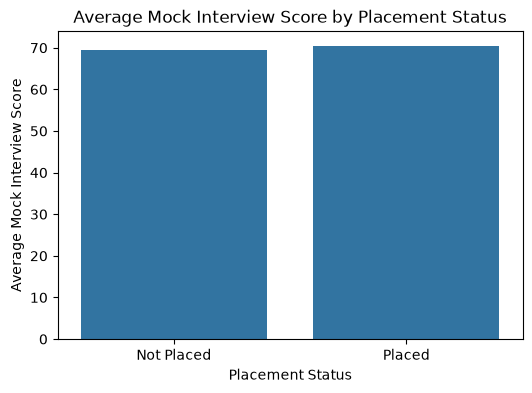

In [21]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=mock_interview_by_placement.index,
    y=mock_interview_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average Mock Interview Score")
plt.title("Average Mock Interview Score by Placement Status")

plt.show()

In [22]:
attendance_by_placement = df_clean.groupby(
    "placement_status"
)["attendance_percentage"].mean()

print(attendance_by_placement)

placement_status
0    84.816148
1    84.658270
Name: attendance_percentage, dtype: float64


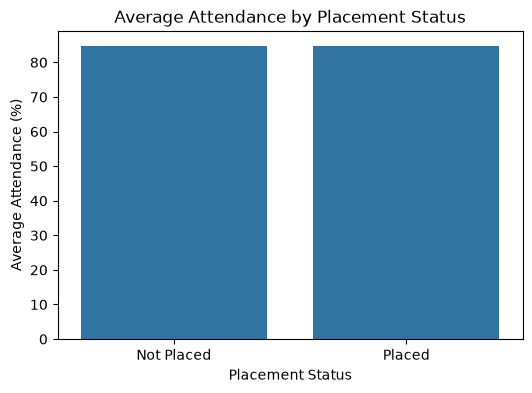

In [23]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=attendance_by_placement.index,
    y=attendance_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average Attendance (%)")
plt.title("Average Attendance by Placement Status")

plt.show()

In [24]:
backlogs_placement = pd.crosstab(
    df_clean["backlogs"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(backlogs_placement)

placement_status           0          1
backlogs                               
0                  42.771500  57.228500
1                  47.986877  52.013123
2                  55.202467  44.797533
3                  60.234375  39.765625
4                  64.640884  35.359116
5                  66.666667  33.333333
6                 100.000000   0.000000


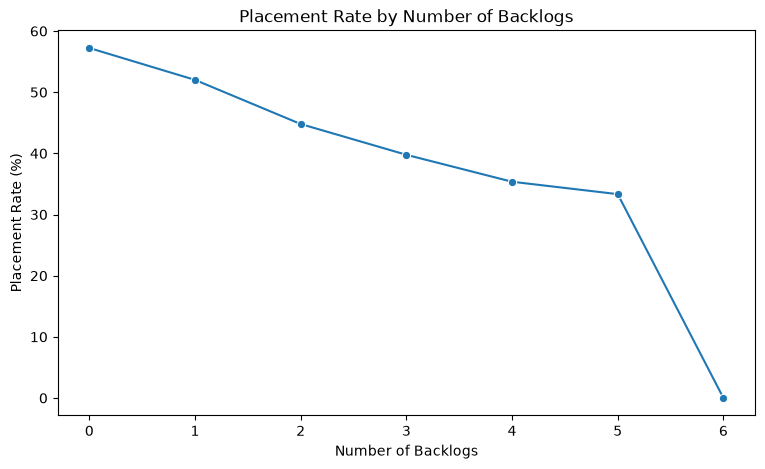

In [25]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    x=backlogs_placement.index,
    y=backlogs_placement[1],
    marker="o"
)

plt.xlabel("Number of Backlogs")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Number of Backlogs")
plt.xticks(backlogs_placement.index)

plt.show()

In [26]:
college_tier_placement = pd.crosstab(
    df_clean["college_tier"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(college_tier_placement)

placement_status          0          1
college_tier                          
Tier 1            45.498735  54.501265
Tier 2            45.715144  54.284856
Tier 3            45.278410  54.721590


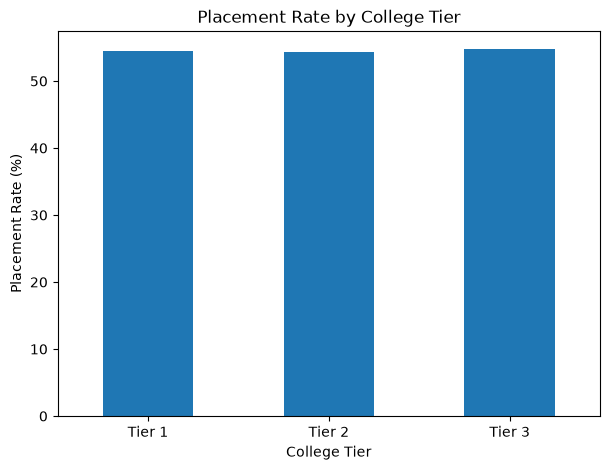

In [27]:
college_tier_placement[1].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("College Tier")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by College Tier")
plt.xticks(rotation=0)

plt.show()

In [28]:
branch_placement = pd.crosstab(
    df_clean["branch"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(branch_placement)


placement_status          0          1
branch                                
CSE               45.355850  54.644150
Civil             44.825866  55.174134
ECE               45.894822  54.105178
EEE               45.681439  54.318561
IT                45.697285  54.302715
Mechanical        45.916443  54.083557


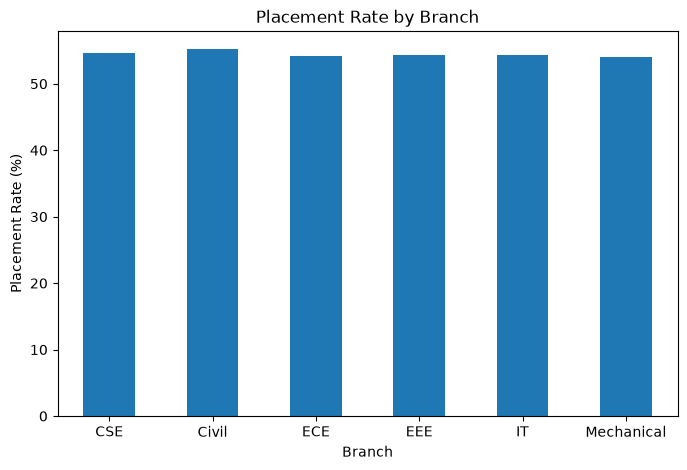

In [29]:
branch_placement[1].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Branch")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Branch")
plt.xticks(rotation=0)

plt.show()

In [30]:
volunteer_placement = pd.crosstab(
    df_clean["volunteer_experience"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(volunteer_placement)

placement_status              0          1
volunteer_experience                      
No                    45.591448  54.408552
Yes                   45.465444  54.534556


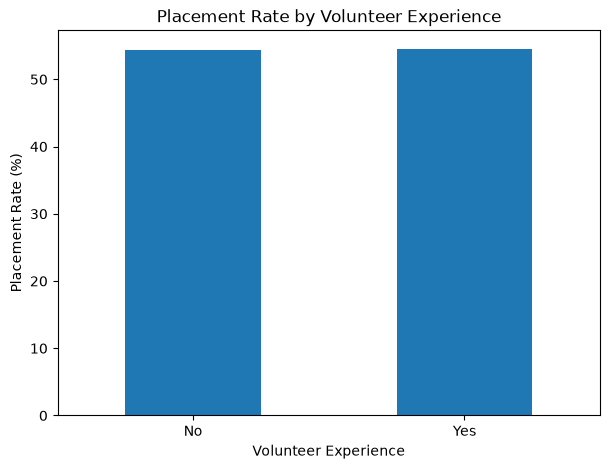

In [31]:
volunteer_placement[1].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Volunteer Experience")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Volunteer Experience")
plt.xticks(rotation=0)

plt.show()

In [32]:
certifications_placement = pd.crosstab(
    df_clean["certifications_count"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(certifications_placement)

placement_status               0           1
certifications_count                        
0                      44.974370   55.025630
1                      45.426100   54.573900
2                      45.830845   54.169155
3                      45.539751   54.460249
4                      45.643793   54.356207
5                      45.718901   54.281099
6                      47.155812   52.844188
7                      45.639535   54.360465
8                      35.616438   64.383562
9                      50.000000   50.000000
10                    100.000000    0.000000
11                      0.000000  100.000000


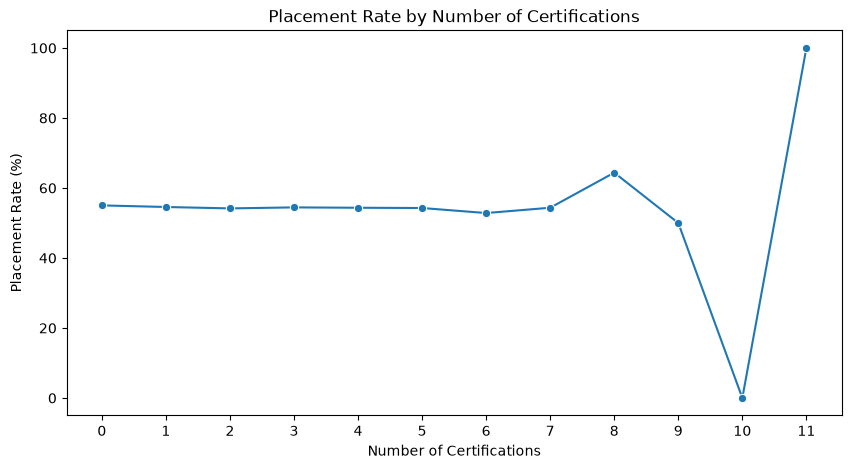

In [33]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=certifications_placement.index,
    y=certifications_placement[1],
    marker="o"
)

plt.xlabel("Number of Certifications")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Number of Certifications")
plt.xticks(certifications_placement.index)

plt.show()

In [34]:
hackathon_placement = pd.crosstab(
    df_clean["hackathons_participated"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(hackathon_placement)

placement_status                  0          1
hackathons_participated                       
0                         45.479549  54.520451
1                         45.618760  54.381240
2                         45.724305  54.275695
3                         45.144357  54.855643
4                         45.513234  54.486766
5                         43.103448  56.896552
6                         21.052632  78.947368
7                         50.000000  50.000000
8                        100.000000   0.000000


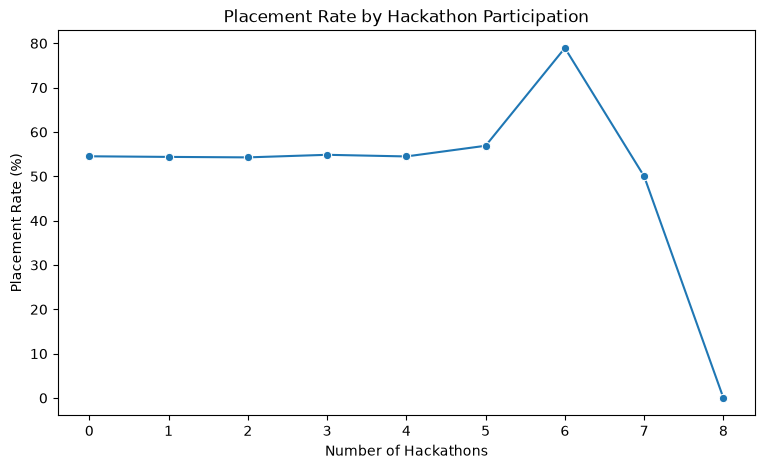

In [35]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    x=hackathon_placement.index,
    y=hackathon_placement[1],
    marker="o"
)

plt.xlabel("Number of Hackathons")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by Hackathon Participation")
plt.xticks(hackathon_placement.index)

plt.show()

In [36]:

github_placement = pd.crosstab(
    df_clean["github_repos"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(github_placement)

placement_status          0           1
github_repos                           
0                 45.286104   54.713896
1                 45.763870   54.236130
2                 46.132466   53.867534
3                 45.510996   54.489004
4                 45.341234   54.658766
5                 45.705066   54.294934
6                 45.317106   54.682894
7                 45.619285   54.380715
8                 44.425957   55.574043
9                 44.427597   55.572403
10                43.516874   56.483126
11                41.262136   58.737864
12                54.716981   45.283019
13                66.666667   33.333333
14                33.333333   66.666667
16                 0.000000  100.000000


In [37]:
# Group GitHub repositories into ranges

df_clean["github_repo_group"] = pd.cut(
    df_clean["github_repos"],
    bins=[-1, 2, 5, 10, 15, 20],
    labels=["0-2", "3-5", "6-10", "11-15", "16-20"]
)

github_group_placement = pd.crosstab(
    df_clean["github_repo_group"],
    df_clean["placement_status"],
    normalize="index"
) * 100

print(github_group_placement)

placement_status           0           1
github_repo_group                       
0-2                45.954652   54.045348
3-5                45.505184   54.494816
6-10               45.174845   54.825155
11-15              45.357143   54.642857
16-20               0.000000  100.000000


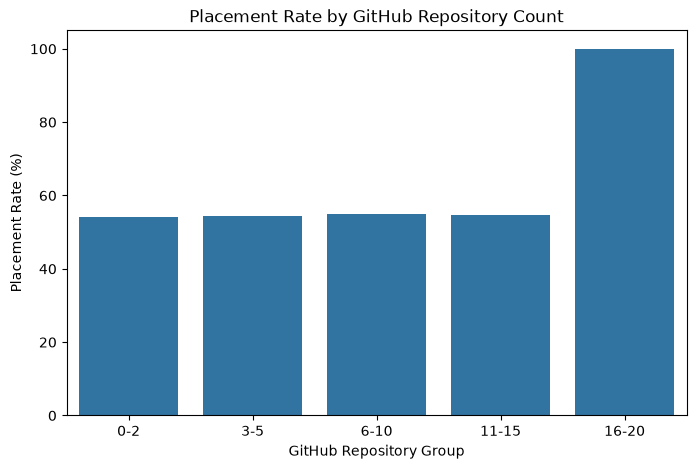

In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=github_group_placement.index,
    y=github_group_placement[1]
)

plt.xlabel("GitHub Repository Group")
plt.ylabel("Placement Rate (%)")
plt.title("Placement Rate by GitHub Repository Count")

plt.show()

In [42]:
leadership_by_placement = df_clean.groupby(
    "placement_status"
)["leadership_score"].mean()

print(leadership_by_placement)

placement_status
0    54.457954
1    55.338565
Name: leadership_score, dtype: float64


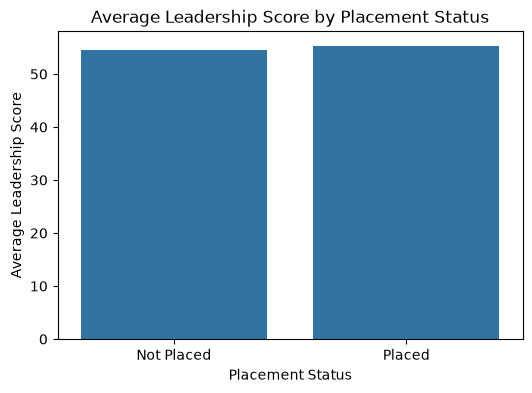

In [43]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=leadership_by_placement.index,
    y=leadership_by_placement.values
)

plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.xlabel("Placement Status")
plt.ylabel("Average Leadership Score")
plt.title("Average Leadership Score by Placement Status")

plt.show()

In [44]:
# TASK 5 — Separate features and target

X = df_clean.drop(columns=["placement_status"])
y = df_clean["placement_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (100000, 24)
y shape: (100000,)

Target distribution:
placement_status
1    54459
0    45541
Name: count, dtype: int64


In [45]:
# Remove temporary EDA column

if "github_repo_group" in X.columns:
    X = X.drop(columns=["github_repo_group"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 23)
y shape: (100000,)


In [47]:
from sklearn.model_selection import train_test_split

print("train_test_split is ready!")

train_test_split is ready!


In [48]:
# 80/20 Stratified Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80000, 23)
X_test shape: (20000, 23)
y_train shape: (80000,)
y_test shape: (20000,)


In [49]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
placement_status
1    54.45875
0    45.54125
Name: proportion, dtype: float64

Testing target distribution:
placement_status
1    54.46
0    45.54
Name: proportion, dtype: float64


In [50]:
categorical_features = X.select_dtypes(include=["object", "str"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object", "str"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

Categorical features:
['gender', 'branch', 'college_tier', 'volunteer_experience']

Number of categorical features: 4

Numerical features:
['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']

Number of numerical features: 19


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [52]:
handle_unknown="ignore"

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [54]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [55]:
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated!")

Predictions generated!


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Evaluation metrics ready!")

Evaluation metrics ready!


In [58]:
# Logistic Regression Evaluation

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Not Placed", "Placed"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Results
---------------------------
Accuracy : 0.57005
Precision: 0.5788894240693594
Recall   : 0.77240176276166
F1 Score : 0.6617895771878073

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.55      0.33      0.41      9108
      Placed       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.56      0.57      0.55     20000

Confusion Matrix:
[[2988 6120]
 [2479 8413]]


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [60]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [61]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [62]:
# Random Forest Evaluation

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Not Placed", "Placed"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.55265
Precision: 0.5708251401937222
Recall   : 0.7196107234667646
F1 Score : 0.6366405393331438

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.51      0.35      0.42      9108
      Placed       0.57      0.72      0.64     10892

    accuracy                           0.55     20000
   macro avg       0.54      0.54      0.53     20000
weighted avg       0.54      0.55      0.54     20000

Confusion Matrix:
[[3215 5893]
 [3054 7838]]


In [63]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(
            kernel="rbf",
            C=1.0,
            random_state=42
        ))
    ]
)

print("SVM pipeline created!")

SVM pipeline created!


In [ ]:
svm_model.fit(X_train, y_train)

print("SVM trained successfully!")

In [2]:
# ============================================================
# PROJECT SETUP — Student Placement Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. Load dataset
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")

# 2. Clean dataset
df_clean = df.copy()

# Remove ID and salary (salary is unavailable before placement)
df_clean = df_clean.drop(
    columns=["student_id", "salary_package_lpa"]
)

# 3. Encode target
df_clean["placement_status"] = df_clean["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})

# 4. Separate X and y
X = df_clean.drop(columns=["placement_status"])
y = df_clean["placement_status"]

# 5. Identify features
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object", "str"]
).columns.tolist()

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 7. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("========================================")
print("PROJECT SETUP COMPLETE")
print("========================================")
print("Dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)
print("X shape:", X.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Categorical features:", categorical_features)
print("Numerical features:", len(numerical_features))
print("========================================")

PROJECT SETUP COMPLETE
Dataset shape: (100000, 26)
Clean dataset shape: (100000, 24)
X shape: (100000, 23)
Training shape: (80000, 23)
Testing shape: (20000, 23)
Categorical features: ['gender', 'branch', 'college_tier', 'volunteer_experience']
Numerical features: 19


In [3]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(
            kernel="linear",
            C=1.0,
            random_state=42
        ))
    ]
)

print("Linear SVM pipeline created!")

Linear SVM pipeline created!


In [ ]:
from sklearn.svm import LinearSVC

In [1]:
# ============================================================
# PROJECT SETUP — Student Placement Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. Load dataset
df = pd.read_csv("student_placement_prediction_dataset_2026.csv")

# 2. Clean dataset
df_clean = df.copy()

# Remove ID and salary (salary is unavailable before placement)
df_clean = df_clean.drop(
    columns=["student_id", "salary_package_lpa"]
)

# 3. Encode target
df_clean["placement_status"] = df_clean["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})

# 4. Separate X and y
X = df_clean.drop(columns=["placement_status"])
y = df_clean["placement_status"]

# 5. Identify features
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object", "str"]
).columns.tolist()

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 7. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("========================================")
print("PROJECT SETUP COMPLETE")
print("========================================")
print("Dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)
print("X shape:", X.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Categorical features:", categorical_features)
print("Numerical features:", len(numerical_features))
print("========================================")

PROJECT SETUP COMPLETE
Dataset shape: (100000, 26)
Clean dataset shape: (100000, 24)
X shape: (100000, 23)
Training shape: (80000, 23)
Testing shape: (20000, 23)
Categorical features: ['gender', 'branch', 'college_tier', 'volunteer_experience']
Numerical features: 19


In [2]:
from sklearn.svm import LinearSVC

In [3]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LinearSVC(
            C=1.0,
            random_state=42,
            max_iter=2000
        ))
    ]
)

print("Fast SVM pipeline created!")

Fast SVM pipeline created!


In [4]:
svm_model.fit(X_train, y_train)

print("Fast SVM trained successfully!")

Fast SVM trained successfully!


In [6]:
print("svm_model exists:", "svm_model" in globals())
print("X_test exists:", "X_test" in globals())

svm_model exists: True
X_test exists: True


In [7]:
y_pred_svm = svm_model.predict(X_test)

print("SVM predictions generated!")

SVM predictions generated!


In [8]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("-----------")
print("Accuracy :", accuracy_svm)
print("Precision:", precision_svm)
print("Recall   :", recall_svm)
print("F1 Score :", f1_svm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Not Placed", "Placed"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Results
-----------
Accuracy : 0.56965
Precision: 0.5784845778663186
Recall   : 0.7731362467866324
F1 Score : 0.6617941765884711

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.55      0.33      0.41      9108
      Placed       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.56      0.57      0.55     20000

Confusion Matrix:
[[2972 6136]
 [2471 8421]]


In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1
        ))
    ]
)

print("KNN pipeline created!")

KNN pipeline created!


In [10]:
knn_model.fit(X_train, y_train)

print("KNN trained successfully!")

KNN trained successfully!


In [11]:
y_pred_knn = knn_model.predict(X_test)

print("KNN predictions generated!")

KNN predictions generated!


In [12]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("KNN Results")
print("-----------")
print("Accuracy :", accuracy_knn)
print("Precision:", precision_knn)
print("Recall   :", recall_knn)
print("F1 Score :", f1_knn)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=["Not Placed", "Placed"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Results
-----------
Accuracy : 0.52115
Precision: 0.55622060709705
Recall   : 0.597227322805729
F1 Score : 0.575995041395493

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.47      0.43      0.45      9108
      Placed       0.56      0.60      0.58     10892

    accuracy                           0.52     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.52      0.52      0.52     20000

Confusion Matrix:
[[3918 5190]
 [4387 6505]]


In [14]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy": [
        0.57005,
        0.55265,
        0.56965,
        0.52115
    ],
    "Precision": [
        0.578889,
        0.570825,
        0.578485,
        0.556221
    ],
    "Recall": [
        0.772402,
        0.719611,
        0.773136,
        0.597227
    ],
    "F1 Score": [
        0.661790,
        0.636641,
        0.661794,
        0.575995
    ]
})

print(model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.5700     0.5789  0.7724    0.6618
1        Random Forest    0.5526     0.5708  0.7196    0.6366
2                  SVM    0.5696     0.5785  0.7731    0.6618
3                  KNN    0.5212     0.5562  0.5972    0.5760


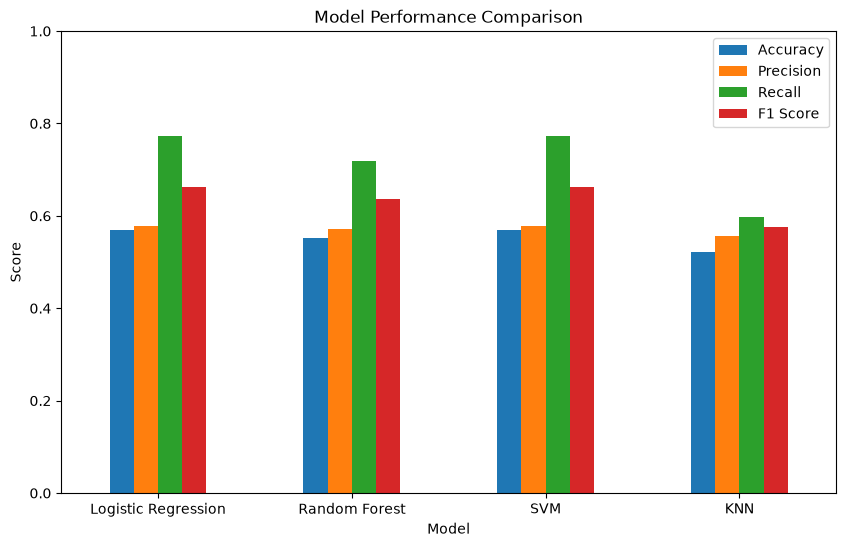

In [15]:
model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend()
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression recreated and trained!")

Logistic Regression recreated and trained!


In [18]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 20 features:")

print(feature_names[:20])

Number of features: 32

First 20 features:
['num__age' 'num__cgpa' 'num__internships_count' 'num__projects_count'
 'num__certifications_count' 'num__coding_skill_score'
 'num__aptitude_score' 'num__communication_skill_score'
 'num__logical_reasoning_score' 'num__hackathons_participated'
 'num__github_repos' 'num__linkedin_connections'
 'num__mock_interview_score' 'num__attendance_percentage' 'num__backlogs'
 'num__extracurricular_score' 'num__leadership_score' 'num__sleep_hours'
 'num__study_hours_per_day' 'cat__gender_Female']


In [19]:
coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(feature_importance.head(15))

                           Feature  Coefficient  Absolute_Coefficient
14                   num__backlogs    -0.172704              0.172704
2           num__internships_count     0.128343              0.128343
3              num__projects_count     0.126298              0.126298
5          num__coding_skill_score     0.106354              0.106354
12       num__mock_interview_score     0.094282              0.094282
8     num__logical_reasoning_score     0.073885              0.073885
6              num__aptitude_score     0.066454              0.066454
7   num__communication_skill_score     0.062122              0.062122
16           num__leadership_score     0.046627              0.046627
15      num__extracurricular_score     0.040599              0.040599
20                cat__gender_Male     0.039648              0.039648
31   cat__volunteer_experience_Yes     0.037852              0.037852
30    cat__volunteer_experience_No     0.035464              0.035464
22               cat

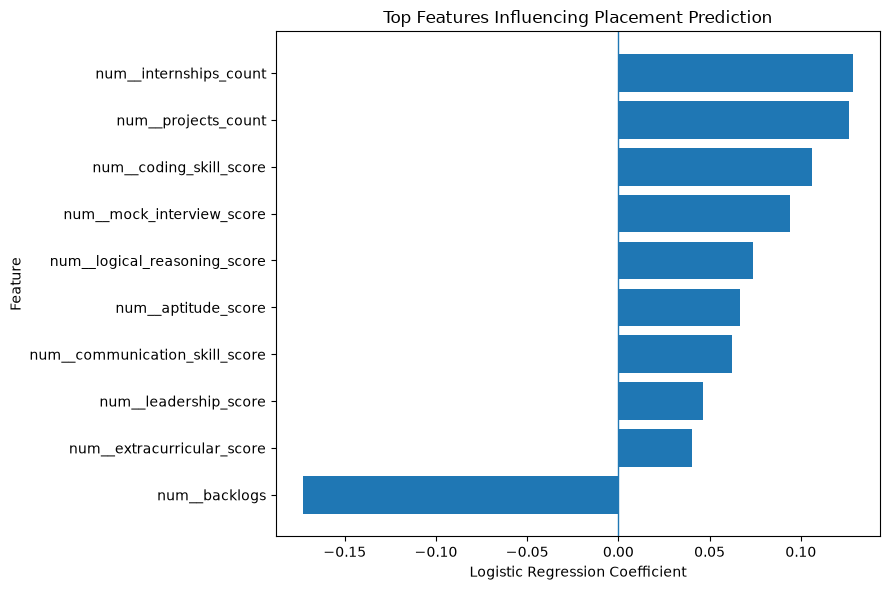

In [20]:
top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Placement Prediction")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

# Conclusion

This project developed a machine learning system to predict student placement outcomes using academic performance, technical skills, internship experience, projects, interview performance, extracurricular activities, and other student-related factors.

## Key EDA Findings

The exploratory data analysis revealed several important patterns:

- Internship experience showed a positive association with placement. Placement rates generally increased as the number of internships increased.
- Backlogs showed a clear negative association with placement. Students with more backlogs generally had lower placement rates.
- Coding skill, aptitude, communication skill, logical reasoning, mock interview performance, and leadership showed small positive differences between placed and non-placed students.
- Attendance showed almost no difference between placed and non-placed students.
- College tier and branch showed relatively small differences in placement rates.
- Volunteer experience also showed very little difference in placement outcomes.
- Certifications, hackathons, and GitHub repository counts showed relatively weak relationships for the commonly observed ranges, while extreme categories should be interpreted cautiously because they may contain few observations.

## Model Comparison

Four classification algorithms were evaluated:

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 57.00% | 57.89% | 77.24% | 66.18% |
| Random Forest | 55.26% | 57.08% | 71.96% | 63.66% |
| SVM | 56.96% | 57.85% | 77.31% | 66.18% |
| KNN | 52.12% | 55.62% | 59.72% | 57.60% |

## Best Model

Logistic Regression was selected as the final model because it achieved the highest accuracy at approximately 57.00% and essentially matched SVM in F1-score.

SVM achieved a slightly higher recall than Logistic Regression, but the difference was very small.

## Feature Interpretation

The Logistic Regression coefficients showed that backlogs had the strongest negative association with placement prediction.

The strongest positive coefficients included:

- Internships
- Projects
- Coding skill
- Mock interview score
- Logical reasoning
- Aptitude
- Communication skill
- Leadership

These coefficients represent relationships learned by the model and should not be interpreted as proof of causation.

## Limitations

The models achieved moderate predictive performance, with accuracy around 52%–57%. This indicates that the available features do not completely explain student placement outcomes.

The dataset may also contain limitations such as synthetic or simplified relationships between variables. Some high-count categories contained relatively few observations, making their placement rates less reliable.

## Future Improvements

Future work could improve the system by:

- Hyperparameter tuning
- Trying Gradient Boosting or XGBoost
- Feature engineering
- Cross-validation
- Class-weight optimization
- Probability calibration
- Threshold tuning
- More detailed analysis of feature interactions
- Testing the model on an independent real-world dataset
- Deploying the final model using Streamlit or Flask

Overall, the project demonstrates a complete machine learning workflow from data cleaning and exploratory analysis to preprocessing, model training, evaluation, comparison, and interpretation.

In [ ]:
print("PROJECT COMPLETE!")
print("Best Model: Logistic Regression")
print("Accuracy: 57.00%")
print("F1 Score: 66.18%")